### 第15章 霍夫变换
#### 15.1 霍夫直线变换
- 霍夫变换是一种在图像中寻找直线、圆形以及其他简单形状的方法
- 与笛卡尔坐标系对应，构造一个霍夫坐标系。在霍夫坐标系中，横坐标为笛卡尔坐标系中直线的斜率$k$，纵坐标是笛卡尔坐标系中直线的截距$b$
- 如果在笛卡尔空间内，有$N$个点能连成一条直线$y=k_{1}x+b_{1}$，那么在霍夫空间内就会有$N$条直线穿过对应的点$(k_{1}, b_{1})$。或者反过来说，如果在霍夫空间中，有越多的直线穿过点$(k_{1}, b_{1})$，则在笛卡尔空间内有越多的点位于斜率为$k_{1}$，截距为斜率$b_{1}$的直线$y=k_{1}x+b_{1}$上
- 霍夫变换选择直线的基本思想是：选择有尽可能多直线交汇的点

- 函数 `lines = cv2.HoughLines(image, rho, theta, threshold)` 实现霍夫直线变换，源图像需要进行二值化，或者进行Canny边缘检测
    - `image` 是输入图像，必须是8位单通道二值图像
    - `rho` 是以像素为单位的距离r的精度，一般情况下，精度是1
    - `theta` 为角度$\theta$的精度，一般情况下，使用$\pi/180$，表示要搜索所有可能的角度
    - `threshold` 是阈值。在判定直线是否存在时，对直线所穿过的点的数量进行判断，若直线穿过的点的数量小于阈值，说明这些点在算法上构成直线，但在源图像中该直线并不存在；如果大于阈值，则认为直线存在。所以，阈值越小，就会得到越多的直线；阈值越大，得到的直线越少
    - `lines` 中的每一个元素是一对浮点数，表示检测到的直线参数 $(r, \theta)$

(np.float64(-0.5), np.float64(459.5), np.float64(459.5), np.float64(-0.5))

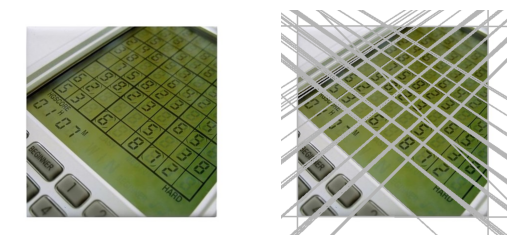

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('computer.jpg')
# img = cv2.imread("building.jpg")  # 该图的霍夫变换会有严重误检测
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray,50,150,apertureSize = 3)
orgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
oShow=orgb.copy()
lines = cv2.HoughLines(edges, 1, np.pi/180, 150)
for line in lines:
    rho, theta = line[0]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))
    cv2.line(orgb, (x1,y1), (x2,y2), (180,180,180),2)
plt.subplot(121)
plt.imshow(oShow)
plt.axis('off')
plt.subplot(122)
plt.imshow(orgb)
plt.axis('off')

- 函数 `lines = cv2.HoughLinesP(image, rho, theta, threshold, minLineLength, maxLineGap)` 实现概率霍夫变换，这是对霍夫变换的修正。
    - `image` 是输入图像，必须是8位单通道二值图像
    - `rho` 是以像素为单位的距离r的精度，一般情况下，精度是1
    - `theta` 为角度$\theta$的精度，一般情况下，使用$\pi/180$，表示要搜索所有可能的角度
    - `threshold` 是阈值。该值越小，判定出的直线越多；反之，判定出的直线越少。
    - `minLineLength` 用来控制“接受直线的最小长度”，默认值为 0
    - `maxLineGap` 用来控制接受直线时的最大像素点间距。如果两点间隔超过该值，则认为这两点不在一条线上，默认值为 0
    - 返回值 `lines` 是 `numpy.ndarray` 类型的元素构成，其中每个元素表示检测到的线段参数，即$(x_{1}, y_{1}, x_{2}, y_{2}$，表示每个检测到的线段的端点

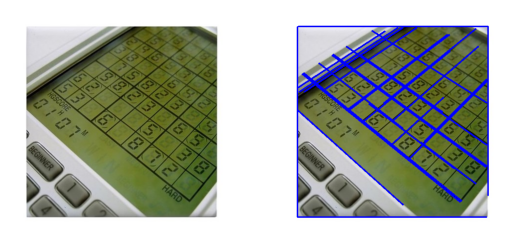

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("computer.jpg", cv2.IMREAD_UNCHANGED)  # 以原始方式读取图像
# img = cv2.imread("building.jpg", cv2.IMREAD_UNCHANGED)  # 可以正常的检测直线
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150, apertureSize=3)
orgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
oShow = orgb.copy()
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 160, minLineLength=100, maxLineGap=10)
for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(orgb, (x1, y1), (x2, y2), (0, 0, 255), 2)
plt.subplot(121)
plt.imshow(oShow)
plt.axis("off")
plt.subplot(122)
plt.imshow(orgb)
plt.axis("off")
plt.show()

#### 15.2 霍夫圆变换
- 用霍夫圆变换检测图像中的圆，OpenCV中采用的策略是两轮筛选。第1轮筛选找出可能存在圆的位置（圆心）；第2轮再根据第1轮的结果筛选出半径大小
- `circles = cv2.HoughCircles(image, method, dp, minDist, param1, param2, minRadius, maxRadius)` 实现霍夫圆变换，其中
    - `image` 是输入图像，类型为8位单通道灰度图像
    - `method` 当前可取 `cv2.HOUGH_GRADIENT` 是经典的梯度霍夫圆检测方法; `cv2.HOUGH_GRADIENT_ALT` 是替代的改进算法，某些情况下检测效果更稳定
    - `dp` 累计器分辨率，用来指定图像分辨率与圆心累加器分辨率的比例
    - `minDist` 圆心间的最小间距。如果存在多个圆心间距小于该值的多个圆，仅有一个会被检测出来
    - `param1` 缺省参数值100，对应的是Canny边缘检测的高阈值（低阈值是高阈值的二分之一）
    - `param2` 圆心位置必须达到的投票数，只有在第1轮筛选过程中，投票数超过该值的圆，才能进入第2轮筛选，缺省值为100
    - `minRadius` 圆半径的最小值，小于该值的圆不会被检测出来，缺省值为 0
    - `maxRadius` 圆半径的最大值，大于该值的圆不会被检测出来，缺省值为 0
    - `circles` 返回值由圆心坐标和半径构成的 `numpy.ndarray`
- 注意：在调用 `cv2.HoughCircles()` 之前，要对源图像进行平滑操作，以减少图像中的噪声，避免发生误判

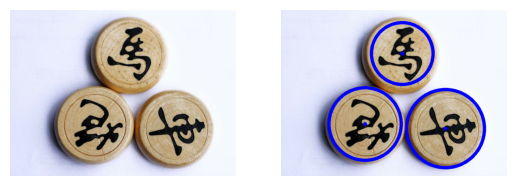

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("chess.jpg", cv2.IMREAD_GRAYSCALE)
imgo = cv2.imread("chess.jpg", cv2.IMREAD_UNCHANGED)
o = cv2.cvtColor(imgo, cv2.COLOR_BGR2RGB)
oshow = o.copy()
img = cv2.medianBlur(img, 5)
# `cv2.HOUGH_GRADIENT` = 3; `cv2.HOUGH_GRADIENT_ALT` = 4
circles = cv2.HoughCircles(img, 3, 1, 300, param1=50, param2=30, minRadius=100, maxRadius=200)
circles = np.uint16(np.around(circles))
for i in circles[0, :]:
    cv2.circle(o, (i[0], i[1]), i[2], (0, 0, 255), 12)
    cv2.circle(o, (i[0], i[1]), 2, (0, 0, 255), 12)
plt.subplot(121)
plt.imshow(oshow)
plt.axis("off")
plt.subplot(122)
plt.imshow(o)
plt.axis("off")
plt.show()